## Multiple Input Graph - Operation Engine

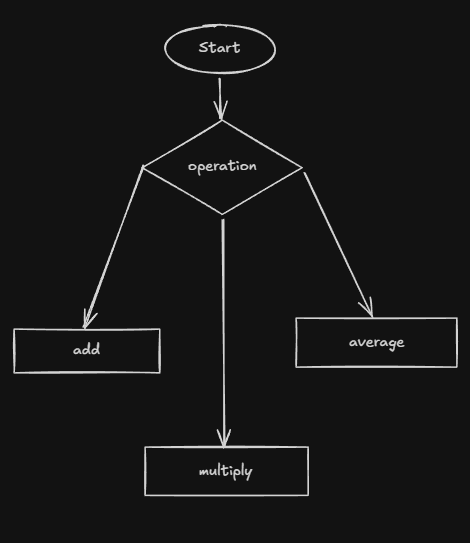

In [18]:
from typing import TypedDict, List
from langgraph.graph import StateGraph, START, END
import math

In [19]:
class AgentState(TypedDict):
    number: List[int]
    operation: str
    result: int

In [20]:
def add(state: AgentState) -> AgentState:
    """This node adds all the numbers in the state."""

    state['result'] = sum(state['number'])
    print(state)
    return state

def multiply(state: AgentState) -> AgentState:
    """This node multiplies all the numbers in the state."""

    state['result'] = math.prod(state['number'])
    print(state)
    return state

def avg(state: AgentState) -> AgentState:
    """This node averages all the numbers in the state."""

    state['result'] = sum(state['number']) / len(state['number'])
    print(state)
    return state

def decide_operation(state: AgentState) -> str:
    """This node decides which operation to perform based on the numbers in the state."""

    if state['operation'] == 'add':
        return 'addition'
    elif state['operation'] == 'multiply':
        return 'multiplication'
    elif state['operation'] == 'avg':
        return 'average'
    else:
        print(f"Unknown operation: {state['operation']}")

In [21]:
graph = StateGraph(AgentState)

graph.add_node("add", add)
graph.add_node("multiply", multiply)
graph.add_node("avg", avg)
graph.add_node("router", lambda state: state)

graph.add_edge(START, "router")
graph.add_conditional_edges(
    "router",
    decide_operation,
    {
        "addition": "add",
        "multiplication": "multiply",
        "average": "avg"
    }
)

graph.add_edge("add", END)
graph.add_edge("multiply", END)
graph.add_edge("avg", END)

app = graph.compile()

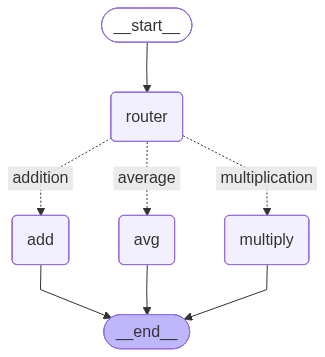

In [22]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [23]:
answer = app.invoke({"number": [2,3,4], "operation": "multiply", "result": 0})
print(answer['result'])

{'number': [2, 3, 4], 'operation': 'multiply', 'result': 24}
24
